In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


In [32]:
df = pd.read_csv("f1_final_dataset.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (23777, 30)
   grid  laps  driver_age  driver_race_count  driver_prev_finish_rate  \
0    16    13   30.929500                 85                 0.285714   
1     5    92   32.301164                 37                 0.361111   
2     7    78   34.713210                 61                 0.383333   
3    11     7   31.036277                  8                 0.000000   
4    23     5   41.092402                105                 0.076923   

   driver_last5_finish_rate  constructor_race_count  \
0                       0.0                       1   
1                       0.0                       2   
2                       0.0                       3   
3                       0.0                       4   
4                       0.0                       5   

   constructor_prev_finish_rate  constructor_prev_avg_grid  \
0                           0.0                   0.000000   
1                           0.0                  16.000000   
2                

In [33]:
df["performance_score"] = (
    -df["grid"] * 0.35
    -df["best_q_time"] * 0.25
    +df["driver_last5_finish_rate"] * 0.20
    +df["constructor_last5_finish_rate"] * 0.15
    +df["circuit_finish_rate"] * 0.05
)

In [34]:
df["position"] = df.groupby(["year", "round"])["performance_score"] \
                   .rank(ascending=False, method="first")


In [35]:
df["win"] = (df["position"] == 1).astype(int)


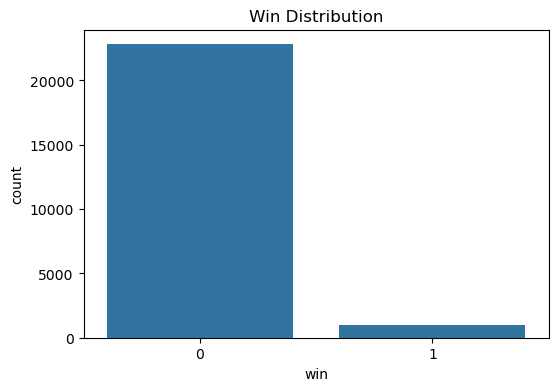

In [36]:
plt.figure(figsize=(6,4))
sns.countplot(x="win", data=df)
plt.title("Win Distribution")
plt.show()


In [37]:
features = [
    "grid",
    "best_q_time",
    "driver_last5_finish_rate",
    "constructor_last5_finish_rate",
    "circuit_finish_rate",
    "laps",
    "driver_age",
    "driver_race_count",
    "constructor_race_count",
    "season_progress"
]

X = df[features]
y = df["win"]

In [38]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [39]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42
)

model.fit(X_train_scaled, y_train)

RandomForestClassifier(max_depth=12, n_estimators=200, random_state=42)

In [41]:
pred = model.predict(X_test_scaled)

print("\nAccuracy:", accuracy_score(y_test, pred))
print("\nClassification Report\n")
print(classification_report(y_test, pred))



Accuracy: 0.979394449116905

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4561
           1       0.82      0.64      0.72       195

    accuracy                           0.98      4756
   macro avg       0.90      0.81      0.85      4756
weighted avg       0.98      0.98      0.98      4756



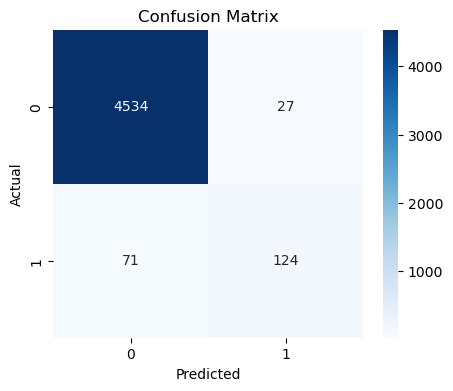

In [42]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

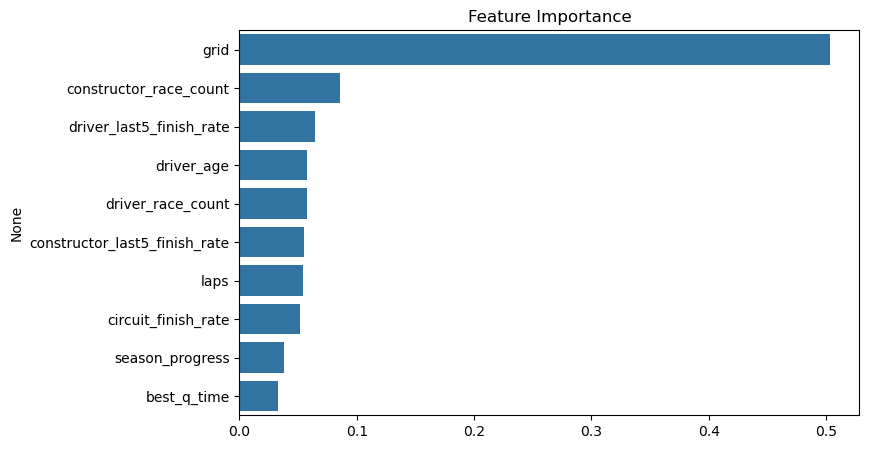

In [43]:
importance = pd.Series(model.feature_importances_, index=features)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importance.values, y=importance.index)
plt.title("Feature Importance")
plt.show()


In [44]:
def predict_contender():

    print("\nEnter Contender Race Parameters\n")

    grid = float(input("Starting Grid Position: "))
    q_time = float(input("Best Qualifying Time (seconds): "))
    driver_form = float(input("Driver Last 5 Finish Rate (0-1): "))
    constructor_form = float(input("Constructor Last 5 Finish Rate (0-1): "))
    circuit_rate = float(input("Circuit Finish Rate (0-1): "))
    laps = float(input("Number of Laps: "))
    driver_age = float(input("Driver Age: "))
    driver_races = float(input("Driver Race Count: "))
    constructor_races = float(input("Constructor Race Count: "))
    season_progress = float(input("Season Progress (0-1): "))

    sample = pd.DataFrame([{
        "grid": grid,
        "best_q_time": q_time,
        "driver_last5_finish_rate": driver_form,
        "constructor_last5_finish_rate": constructor_form,
        "circuit_finish_rate": circuit_rate,
        "laps": laps,
        "driver_age": driver_age,
        "driver_race_count": driver_races,
        "constructor_race_count": constructor_races,
        "season_progress": season_progress
    }])

    sample_scaled = scaler.transform(sample)

    prediction = model.predict(sample_scaled)
    probability = model.predict_proba(sample_scaled)

    if prediction[0] == 1:
        print("\n🏆 This contender is LIKELY to win")
    else:
        print("\n❌ This contender is UNLIKELY to win")

    print("Win Probability:", round(probability[0][1]*100,2), "%")


In [45]:
predict_contender() 


Enter Contender Race Parameters




❌ This contender is UNLIKELY to win
Win Probability: 2.0 %
